<a href="https://colab.research.google.com/github/stellaspir/datastories/blob/main/%CE%95%CF%81%CE%B3%CE%B1%CF%83%CE%AF%CE%B12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib as plt
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import median_absolute_error

In [2]:
train_df=pd.read_csv("/content/τρειν.csv")
test_df=pd.read_csv("/content/τεστ.csv")

In [3]:
train_df.copy()

,ID,Tag,Reputation,Answers,Username,Views,Upvotes
0,52664,a,3942.0,2.0,155623,7855.0,42.0
1,327662,a,26046.0,12.0,21781,55801.0,1175.0
2,468453,c,1358.0,4.0,56177,8067.0,60.0
3,96996,a,264.0,3.0,168793,27064.0,9.0
4,131465,c,4271.0,4.0,112223,13986.0,83.0
...,...,...,...,...,...,...,...
330040,339800,c,36.0,2.0,84919,1063.0,0.0
330041,253800,c,1649.0,2.0,76730,23319.0,73.0
330042,210756,c,6178.0,2.0,91701,2453.0,15.0
330043,56089,j,89.0,2.0,80245,2107.0,3.0


In [5]:
train_df.shape,test_df.shape

((330045, 7), (141448, 6))

In [6]:
train_df.drop(['ID','Username'],axis=1,inplace=True)

In [7]:
X=train_df.drop("Upvotes",axis=1)
y=train_df['Upvotes']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=44,shuffle=True)

In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [11]:
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

model.fit(X_train_processed_df, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test_processed_df)

In [15]:
from sklearn.metrics import mean_absolute_error
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

In [16]:
print('MAE is {}'.format(MAE))
print('MSE is {}'.format(MSE))
print('RMSE is {}'.format(RMSE))

MAE is 585.5421989891088
MSE is 4535929.941995859
RMSE is 2129.772274680056


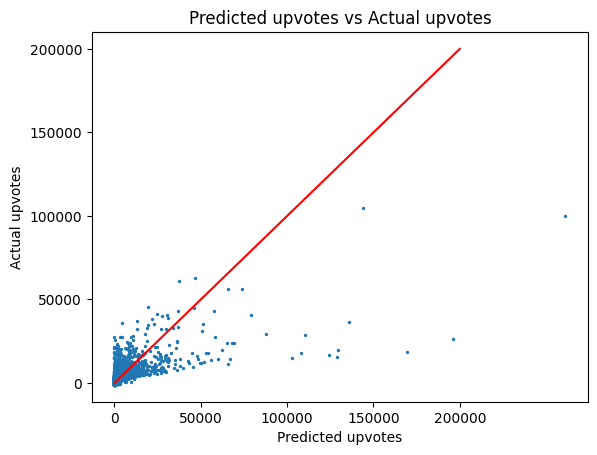

<Figure size 640x480 with 0 Axes>

In [18]:
plt.scatter(y_test, y_pred, s = 2)
plt.xlabel("Predicted upvotes")
plt.ylabel("Actual upvotes")
plt.title("Predicted upvotes vs Actual upvotes")

plt.xticks(np.arange(0, 250000, step=50000))
plt.yticks(np.arange(0, 250000, step=50000))

plt.plot(np.arange(0, 250000, step=50000), np.arange(0, 250000, step=50000), color = 'red')
plt.show()
plt.clf()